# Datathon - Plataforma de Experimentação Adaptativa de Ofertas

**Base Kaggle:** [bank-marketing (henriqueyamahata)](https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing) - arquivo `bank-additional-full.csv` (mesma distribuição do repositório UCI Bank Marketing, versão "additional").

Este notebook cobre as **Etapas 1 a 4** do desafio:

1. **Etapa 1 - EDA**: análise exploratória e tratamento de dados.
2. **Etapa 2 - Preparação da base**: features do cliente + variável alvo (`converted`), removendo a coluna de vazamento temporal `duration`.
3. **Etapa 3 - Baseline vs. política adaptativa**: regra fixa vs. Epsilon-Greedy vs. Thompson Sampling (avaliação *offline replay*).
4. **Etapa 4 - Avaliação e Golden Set**: métricas comparativas e 5 casos de teste com as recomendações geradas.

**Formulação do problema como bandit:** cada contato de campanha é uma decisão. Os **braços** são os canais/abordagens de contato (`cellular` vs. `telephone`), a **recompensa** é a conversão observada (`y = yes`, assinatura do depósito a prazo) e o **contexto** é o segmento do cliente (faixa etária × posse de crédito). A avaliação usa *replay* (Li et al., 2011), contabilizando eventos em que a política escolheu o braço registrado. Como a política de coleta não foi aleatória e suas propensões são desconhecidas, esta é uma comparação sujeita a viés de seleção, não uma estimativa causal de uplift.


In [1]:
# Configuração: garante que o pacote src/ (raiz do repositório) esteja no path
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data_prep import download_raw, prepare

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

# Etapa 1 - download da base (mesmo arquivo distribuído no Kaggle)
raw_path = download_raw()
raw = pd.read_csv(raw_path, sep=";")
print(raw.shape)
raw.head()


(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Etapa 1 - Análise Exploratória (EDA)

Estrutura, valores ausentes (codificados como `unknown`), balanceamento do alvo e relação das principais variáveis com a conversão.


In [2]:
# Visão geral: tipos, cardinalidade e valores 'unknown' por coluna
overview = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "n_unique": raw.nunique(),
        "pct_unknown": (raw == "unknown").mean().round(4) * 100,
    }
)
print(f"Duplicatas: {raw.duplicated().sum()}")
print(f"Taxa de conversão global (y=yes): {(raw['y'] == 'yes').mean():.2%}")
overview


Duplicatas: 12
Taxa de conversão global (y=yes): 11.27%


,dtype,n_unique,pct_unknown
age,int64,78,0.00
job,object,12,0.80
marital,object,4,0.19
education,object,8,4.20
default,object,3,20.87
housing,object,3,2.40
loan,object,3,2.40
contact,object,2,0.00
month,object,10,0.00
day_of_week,object,5,0.00


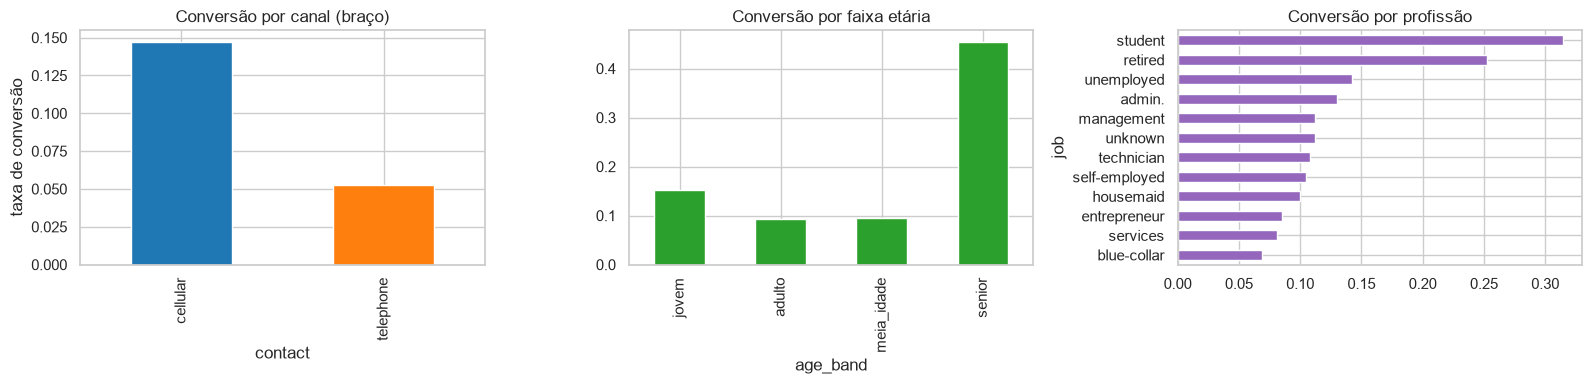

In [3]:
# Conversão por canal de contato, faixa etária e profissão
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

raw.groupby("contact")["y"].apply(lambda s: (s == "yes").mean()).plot(
    kind="bar", ax=axes[0], color=["#1f77b4", "#ff7f0e"], title="Conversão por canal (braço)"
)
axes[0].set_ylabel("taxa de conversão")

age_band = pd.cut(raw["age"], bins=[0, 30, 45, 60, 200], labels=["jovem", "adulto", "meia_idade", "senior"])
raw.assign(age_band=age_band).groupby("age_band", observed=True)["y"].apply(
    lambda s: (s == "yes").mean()
).plot(kind="bar", ax=axes[1], color="#2ca02c", title="Conversão por faixa etária")

raw.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values().plot(
    kind="barh", ax=axes[2], color="#9467bd", title="Conversão por profissão"
)

plt.tight_layout()
plt.show()


## Etapa 2 - Preparação da base

A base já possui variável clara de conversão (`y`), então é usada diretamente, sem dados sintéticos. O tratamento:

- **Deduplicação** dos registros brutos idênticos, antes da remoção de colunas.
- **Remoção de vazamento temporal**: `duration` só é conhecida após a ligação terminar, sendo descartada conforme recomendação da própria documentação da base.
- **Alvo**: `converted = 1` se `y == "yes"`.
- **Braço logado**: `arm = contact` (canal usado no contato histórico).
- **Contexto**: `segment` = faixa etária × posse de crédito (`housing`/`loan`), sem usar atributos sensíveis (gênero, raça, renda e patrimônio não existem na base).


In [4]:
df = prepare()
print(f"Base preparada: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("\nTaxa de conversão por braço (log histórico):")
print(df.groupby("arm")["converted"].agg(["mean", "count"]).round(4))
df[["age", "job", "housing", "loan", "segment", "arm", "converted"]].head()


Base preparada: 41176 linhas x 23 colunas

Taxa de conversão por braço (log histórico):
             mean  count
arm                     
cellular   0.1474  26135
telephone  0.0523  15041


,age,job,housing,loan,segment,arm,converted
0,56,housemaid,no,no,meia_idade_sem_credito,telephone,0
1,57,services,no,no,meia_idade_sem_credito,telephone,0
2,37,services,yes,no,adulto_com_credito,telephone,0
3,40,admin.,no,no,adulto_sem_credito,telephone,0
4,56,services,no,yes,meia_idade_com_credito,telephone,0


## Etapa 3 - Baseline e política adaptativa

- **Baseline determinístico (regra fixa)**: sempre usar o canal incumbente `telephone`, representando a regra estática que a instituição usaria sem experimentação.
- **Melhor braço histórico (oráculo)**: sempre `cellular`, teto de referência que só é conhecido *depois* de olhar o log inteiro.
- **Epsilon-Greedy** (`ε = 0.1`): explora 10% do tráfego, explota o melhor braço empírico no restante.
- **Thompson Sampling** (prior `Beta(1,1)`, uniforme e não-informativa): amostra da posterior de cada braço e escolhe o maior, de modo que a exploração diminui naturalmente conforme a incerteza cai.
- **Thompson Sampling contextual**: uma posterior por (segmento, braço).

O ponto-chave: o bandit deve **aprender** o melhor braço sem conhecê-lo de antemão, aproximando-se do oráculo e superando com folga a regra fixa.


In [5]:
# Comparação via replay offline: mesma rotina usada em src/train.py (com MLflow)
from src.bandits import BaselinePolicy, EpsilonGreedy, ThompsonSampling, replay_evaluation

SEED = 42
events = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
arms = sorted(events["arm"].unique().tolist())

policies = {
    "baseline_fixed (telephone)": BaselinePolicy(arms, fixed_arm="telephone", seed=SEED),
    "best_historical_arm (cellular)": BaselinePolicy(arms, fixed_arm="cellular", seed=SEED),
    "epsilon_greedy (e=0.1)": EpsilonGreedy(arms, epsilon=0.1, seed=SEED),
    "thompson_sampling": ThompsonSampling(arms, seed=SEED),
    "thompson_sampling_contextual": ThompsonSampling(arms, contextual=True, seed=SEED),
}

results, histories = [], {}
for name, policy in policies.items():
    m = replay_evaluation(policy, events)
    histories[name] = m["history"]
    results.append({
        "policy": name,
        "conversion_rate": m["conversion_rate"],
        "match_rate": m["match_rate"],
        "matched_events": m["matched_events"],
        "conversions": m["conversions"],
    })

summary = pd.DataFrame(results).sort_values("conversion_rate", ascending=False).reset_index(drop=True)
base_rate = summary.loc[summary["policy"].str.startswith("baseline_fixed"), "conversion_rate"].iloc[0]
summary["uplift_vs_baseline"] = ((summary["conversion_rate"] / base_rate - 1) * 100).round(1).astype(str) + "%"
summary


,policy,conversion_rate,match_rate,matched_events,conversions,uplift_vs_baseline
0,best_historical_arm (cellular),0.147389,0.634714,26135,3852,181.7%
1,thompson_sampling,0.146849,0.632747,26054,3826,180.7%
2,epsilon_greedy (e=0.1),0.144504,0.619487,25508,3686,176.2%
3,thompson_sampling_contextual,0.140451,0.618686,25475,3578,168.4%
4,baseline_fixed (telephone),0.052324,0.365286,15041,787,0.0%


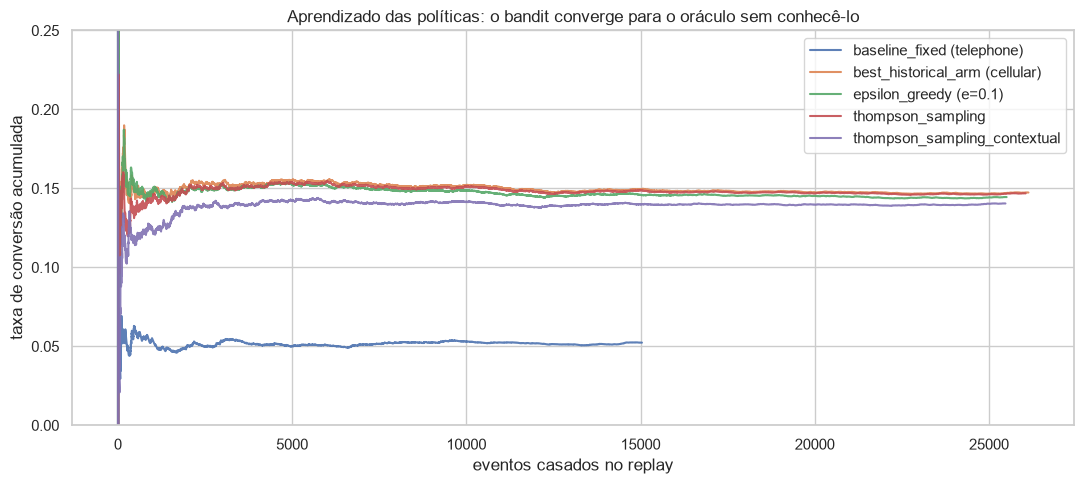

In [6]:
# Análise de exploração: taxa de conversão acumulada ao longo do replay
plt.figure(figsize=(11, 5))
for name, hist in histories.items():
    plt.plot(hist, label=name, alpha=0.9)
plt.xlabel("eventos casados no replay")
plt.ylabel("taxa de conversão acumulada")
plt.title("Aprendizado das políticas: o bandit converge para o oráculo sem conhecê-lo")
plt.legend()
plt.ylim(0, 0.25)
plt.tight_layout()
plt.show()


## Etapa 4 - Avaliação e Golden Set (5 casos de teste)

Métricas de avaliação: **taxa de conversão no replay** (métrica principal), **taxa de casamento**, **uplift vs. baseline** e **posteriores Beta por braço** (evidência da exploração bayesiana). Abaixo, 5 clientes fictícios de perfis distintos recebem a recomendação da política contextual treinada, com verificação de sanidade.


In [7]:
# Golden Set simplificado: 5 clientes -> recomendação + sanidade
from src.data_prep import AGE_BINS, AGE_LABELS

ts_ctx = policies["thompson_sampling_contextual"]

golden_set = pd.DataFrame(
    [
        {"cliente": "C1 - jovem estudante sem crédito", "age": 24, "job": "student", "housing": "no", "loan": "no"},
        {"cliente": "C2 - adulto técnico com financiamento", "age": 38, "job": "technician", "housing": "yes", "loan": "no"},
        {"cliente": "C3 - meia-idade gerente com empréstimo", "age": 52, "job": "management", "housing": "no", "loan": "yes"},
        {"cliente": "C4 - sênior aposentado sem crédito", "age": 67, "job": "retired", "housing": "no", "loan": "no"},
        {"cliente": "C5 - adulto operário com ambos créditos", "age": 33, "job": "blue-collar", "housing": "yes", "loan": "yes"},
    ]
)

def segment_of(row):
    band = pd.cut([row["age"]], bins=AGE_BINS, labels=AGE_LABELS)[0]
    credit = "com_credito" if "yes" in (row["housing"], row["loan"]) else "sem_credito"
    return f"{band}_{credit}"

rows = []
for _, r in golden_set.iterrows():
    seg = segment_of(r)
    arm = ts_ctx.select_arm(seg)
    a, b = ts_ctx.posterior(arm, seg)
    seg_rate = events.loc[events["segment"] == seg].groupby("arm")["converted"].mean()
    best_in_log = seg_rate.idxmax() if not seg_rate.empty else "n/a"
    rows.append(
        {
            "cliente": r["cliente"],
            "segmento": seg,
            "oferta_recomendada": arm,
            "conversao_esperada": round(a / (a + b), 4),
            "melhor_braco_no_log": best_in_log,
            "decisao_faz_sentido": "sim" if arm == best_in_log else "explorando",
        }
    )

pd.DataFrame(rows)


,cliente,segmento,oferta_recomendada,conversao_esperada,melhor_braco_no_log,decisao_faz_sentido
0,C1 - jovem estudante sem crédito,jovem_sem_credito,cellular,0.1971,cellular,sim
1,C2 - adulto técnico com financiamento,adulto_com_credito,cellular,0.1170,cellular,sim
2,C3 - meia-idade gerente com empréstimo,meia_idade_com_credito,cellular,0.1305,cellular,sim
3,C4 - sênior aposentado sem crédito,senior_sem_credito,telephone,0.3636,cellular,explorando
4,C5 - adulto operário com ambos créditos,adulto_com_credito,cellular,0.1170,cellular,sim


## Conclusões e limitações

**Resultados**: no replay sobre 41.176 eventos, o Thompson Sampling alcança 14,68% de conversão nos eventos casados, próximo da referência retrospectiva de 14,74% e acima dos 5,23% da regra fixa. A taxa de casamento foi 63,27%. A prior `Beta(1,1)` foi suficiente dado o volume de eventos; o Epsilon-Greedy paga um custo permanente de exploração de aproximadamente 10% do tráfego.

**Limitações documentadas**:
- Apenas 2 braços reais (canais); em produção haveria mais ofertas/mensagens por braço.
- Avaliação por *replay* descarta eventos não-casados (aproximadamente 37% no Thompson Sampling), reduzindo a amostra efetiva.
- O log histórico não é aleatorizado e não contém propensões da política de coleta; portanto, as taxas estão sujeitas a viés de seleção e não medem uplift causal.
- O replay assume estacionariedade das taxas de conversão.
- Contexto propositalmente simples (idade × crédito) para evitar atributos sensíveis; decisões sensíveis exigem humano no loop (ver README).

Os experimentos com parâmetros e métricas estão registrados no **MLflow** (`python -m src.train` + `mlflow ui`) e o serviço de recomendação está em `src/api.py` (FastAPI).
